In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split

In [9]:
from sklearn.preprocessing import StandardScaler

In [17]:
from sklearn.linear_model import LogisticRegression

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

In [7]:
pip install pandas openpyxl

In [6]:
df=pd.read_excel('/content/loan_approval.xlsx')
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


**Q1. Data Loading & Understanding**

a) Load the dataset into Python.

b) Display the first 5 rows.

c) Check the shape of the dataset.

d) Display the data types of each column.

In [46]:
# a) Load the dataset into Python.

df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [42]:
# b) Display the first 5 rows.

df.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [15]:
# c) Check the shape of the dataset.

df.shape

(2000, 8)

In [18]:
# d) Display the data types of each column.

df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


**Q2. Data Cleaning**

a) Check for missing values in the dataset.

b) Handle missing values appropriately.
                  
c) Identify categorical columns present in the dataset.

In [19]:
# a) Check for missing values in the dataset.

df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


b) Handle missing values appropriately.

A-

There is no missing value in this dataset so no action need to be taken

In [26]:
# c) Identify categorical columns present in the dataset.

print("Categorical columns are:")
print(list(df.select_dtypes(include=['object', 'category']).columns))

Categorical columns are:
['name', 'city']


**Q3. Exploratory Data Analysis (EDA)**

a) Plot the distribution of the target variable.

b) Analyze the relationship between one numerical feature and the target variable.

c) Analyze the relationship between Years of Employment and the target variable

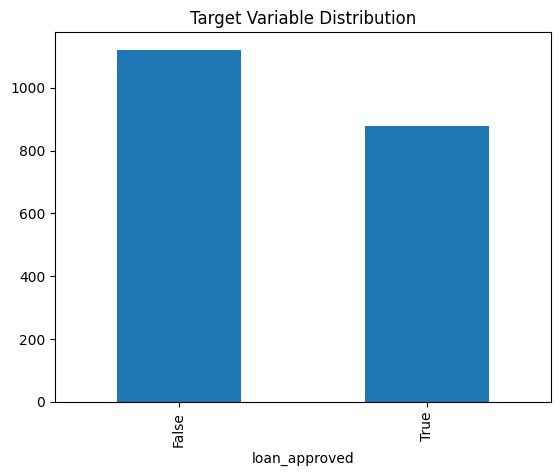

In [31]:
# a) Plot the distribution of the target variable.

df['loan_approved'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.show()

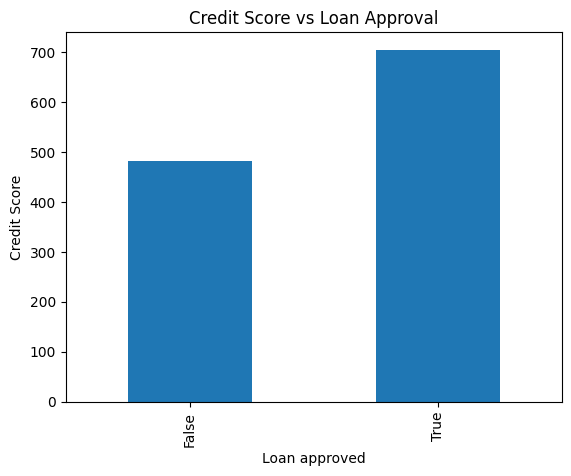

In [33]:
# b) Analyze the relationship between one numerical feature and the target variable.

df.groupby('loan_approved')['credit_score'].mean().plot(kind='bar')
plt.ylabel('Credit Score')
plt.xlabel('Loan Approved')
plt.title('Credit Score vs Loan Approval')
plt.show()

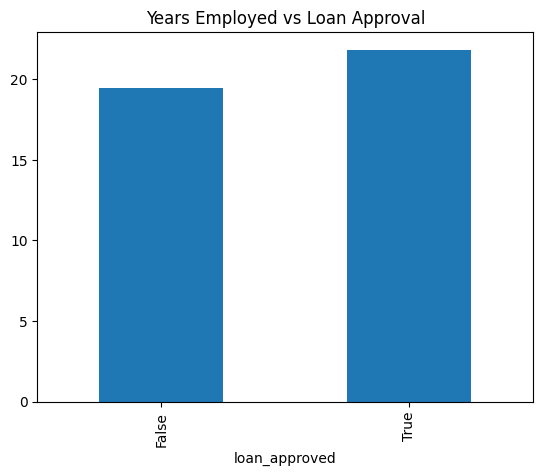

In [34]:
# c) Analyze the relationship between Years of Employment and the target variable

df.groupby('loan_approved')['years_employed'].mean().plot(kind='bar')
plt.title('Years Employed vs Loan Approval')
plt.show()

**Q4. Outlier Detection and Treatment**

a) Detect outliers in numerical columns using the IQR method.

b) Treat outliers using capping techniques

In [51]:
# a) Detect outliers in numerical columns using the IQR method.

for col in ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Outliers in {col}:")
        print(outliers)
    else:
        print(f"No outliers detected in {col}.")

No outliers detected in income.
Outliers in credit_score:
                name          city  income  credit_score  loan_amount  \
10      Justin Baker     Hurstfurt  118696          1285        15373   
108      Connor King   Lake Colton  100010          6548        21246   
114  Elizabeth Ortiz  North Sophia   65382          6110        33284   

     years_employed  points  loan_approved  
10                8      75           True  
108              28      55          False  
114               7      45          False  
No outliers detected in loan_amount.
Outliers in years_employed:
            name               city  income  credit_score  loan_amount  \
8    Patty Perez    Port Leslieview  126530           367        14826   
401  Martin Wise  New Virginiaville   54890           320         4161   

     years_employed  points  loan_approved  
8                66      55          False  
401              70      45          False  
No outliers detected in points.


In [12]:
# b) Treat outliers using capping techniques

for col in ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']:
    Lower_limit = df[col].quantile(0.05)
    Upper_limit = df[col].quantile(0.95)

    df[col] = df[col].clip(lower=Lower_limit, upper=Upper_limit)

    print(f"Outliers in {col} treated.")
    print(f"Lower Cap (5th Percentile) = {Lower_limit}")
    print(f"Upper Cap (95th Percentile) = {Upper_limit}")


Outliers in income treated.
Lower Cap (5th Percentile) = 36867.99475
Upper Cap (95th Percentile) = 143992.000125
Outliers in credit_score treated.
Lower Cap (5th Percentile) = 327.999875
Upper Cap (95th Percentile) = 823.0
Outliers in loan_amount treated.
Lower Cap (5th Percentile) = 3301.99725
Upper Cap (95th Percentile) = 47394.0015
Outliers in years_employed treated.
Lower Cap (5th Percentile) = 2.0
Upper Cap (95th Percentile) = 39.0
Outliers in points treated.
Lower Cap (5th Percentile) = 25.0
Upper Cap (95th Percentile) = 90.0


Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.

In [13]:
df['loan_approved'] = df['loan_approved'].astype(int)
df = df.drop(columns=['name','city'], errors='ignore')
df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810.00000,389.0,39698.0000,27,50,0
1,44592.00000,729.0,15446.0000,28,55,0
2,36867.99475,584.0,11189.0000,13,45,0
3,127196.00000,344.0,47394.0015,29,50,0
4,66048.00000,496.0,47174.0000,4,25,0


**Q6. Feature Selection and Data Splitting**

a) Separate independent variables (X) and dependent variable (y).

b) Split the dataset into training and testing sets.

In [15]:
X = df.drop('loan_approved', axis=1)
numerical_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
X = df[numerical_cols]
y = df['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

**Q7. Apply feature scaling to the dataset using StandardScaler.**

In [16]:
numeric_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scales verified successfully.")
print(f"Scaled Training Mean (Should be approx 0): {X_train_scaled[numeric_cols].mean().round(2).values}")
print(f"Scaled Training Std Dev (Should be approx 1): {X_train_scaled[numeric_cols].std().round(2).values}")

Scales verified successfully.
Scaled Training Mean (Should be approx 0): [-0.  0. -0. -0. -0.]
Scaled Training Std Dev (Should be approx 1): [1. 1. 1. 1. 1.]


**Q8. Logistic Regression Model Building**

a) Train a Logistic Regression model.

b) Predict the output for test data.

In [18]:
# a) Train a Logistic Regression model.

log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

log_reg_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
# b) Predict the output for test data.

y_pred = log_reg_model.predict(X_test_scaled)

print("\nFirst 10 Actual Target Values:     ", list(y_test[:10]))
print("First 10 Predicted Target Values:  ", list(y_pred[:10]))


First 10 Actual Target Values:      [True, False, True, True, False, True, False, True, False, False]
First 10 Predicted Target Values:   [np.True_, np.False_, np.True_, np.True_, np.False_, np.True_, np.False_, np.True_, np.False_, np.False_]


**Q9. Model Evaluation – Confusion Matrix**

a) Generate the confusion matrix.

b) Interpret the results.

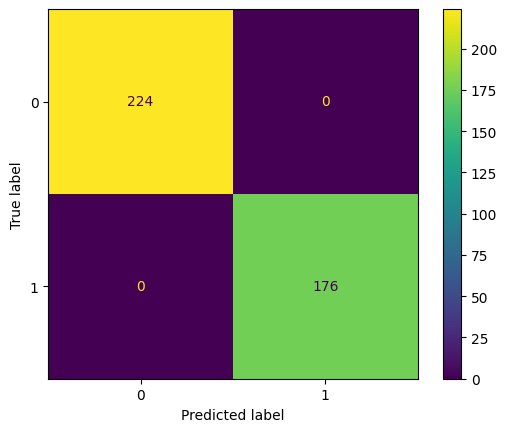

[[224   0]
 [  0 176]]


In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(cm)

**Q10. Model Evaluation – ROC Curve & AUC**

a) Plot the ROC curve.

b) Calculate the AUC score.

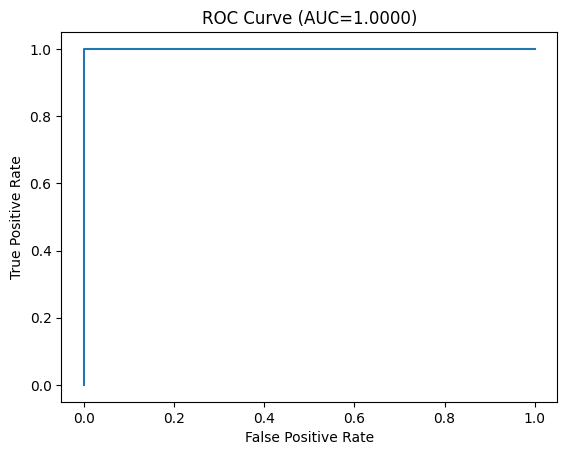

AUC Score: 1.0


In [27]:
y_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC={auc:.4f})')
plt.show()
print('AUC Score:', auc)